<h1 style='color:red' align='center'>Data Science Regression Project: Predicting Home Prices in Banglore</h1>

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline 
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20, 10)

<h2 style='color:blue'>Data Load: Load banglore home prices into a dataframe</h2>

In [3]:
df1 = pd.read_csv("../data/bengaluru_house_prices.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df1.shape

(13320, 9)

In [5]:
# df1.groupby("area_type")["area_type"].agg("count")  | this line is exactly like
df1["area_type"].value_counts()  # | this line

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [6]:
df2 = df1.drop(
    ["area_type", "availability", "society", "balcony"], axis="columns"
).copy()
df2.shape

(13320, 5)

In [7]:
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [8]:
df2.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [10]:
df3 = df2.dropna().copy()
# ? df3 = df2.dropna(axis=1)  # Drops columns with missing values instead of rows.
# ? df3 = df2.dropna(how='all')  # Only drops rows where all values are missing.
# ? df3 = df2.dropna(subset=['A', 'B'])  # Drops rows where columns A or B have missing values.
# ? df2.dropna(inplace=True)  # Modifies df2 directly.
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [11]:
df3["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

<h2 style='color:blue'>Feature Engineering</h2>

**Add new feature(integer) for bhk (Bedrooms Hall Kitchen)**

In [12]:
df3["bhk"] = df3["size"].apply(lambda x: int(x.split(" ")[0]))

In [13]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [14]:
df3["bhk"].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18], dtype=int64)

In [15]:
df3[df3["bhk"] > 20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [16]:
df3.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [17]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [18]:
df3[~df3["total_sqft"].apply(is_float)]

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
...,...,...,...,...,...,...
12975,Whitefield,2 BHK,850 - 1060,2.0,38.190,2
12990,Talaghattapura,3 BHK,1804 - 2273,3.0,122.000,3
13059,Harlur,2 BHK,1200 - 1470,2.0,72.760,2
13265,Hoodi,2 BHK,1133 - 1384,2.0,59.135,2


In [19]:
def convert_sqft_to_num(str):
    tokens = str.split("-")
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(str)
    except:
        return None

In [20]:
df4 = df3.copy()
df4["total_sqft"] = df4["total_sqft"].apply(convert_sqft_to_num)

In [21]:
df4.head(10)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2
5,Whitefield,2 BHK,1170.0,2.0,38.00,2
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3
9,Gandhi Bazar,6 Bedroom,1020.0,6.0,370.00,6


In [22]:
df4.loc[30]

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
bhk                   4
Name: 30, dtype: object

In [23]:
df5 = df4.copy()
df5["price_per_sqft"] = df5["price"] * 100000 / df5["total_sqft"]
df5.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247.863248
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467.057101
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181.818182
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828.244275
9,Gandhi Bazar,6 Bedroom,1020.0,6.0,370.00,6,36274.509804


In [24]:
len(df5.location.unique())

1304

In [25]:
df5.location = df5["location"].apply(lambda x: x.strip())

location_stats = (
    df5.groupby("location")["location"].agg("count").sort_values(ascending=False)
)
location_stats

location
Whitefield               535
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           266
Thanisandra              236
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Karnataka Shabarimala      1
whitefiled                 1
Name: location, Length: 1293, dtype: int64

<h3 style='color:red'>fetch the number of locations that have less than 10 houses </h3>

In [26]:
len(location_stats[location_stats <= 10])

1052

In [27]:
location_stats_less_than_10 = location_stats[location_stats <= 10]

In [28]:
df5.location = df5.location.apply(
    lambda x: "other" if x in location_stats_less_than_10 else x
)
df5.groupby("location")["location"].agg("count").sort_values(ascending=False).head(20)

location
other                       2881
Whitefield                   535
Sarjapur  Road               392
Electronic City              304
Kanakpura Road               266
Thanisandra                  236
Yelahanka                    210
Uttarahalli                  186
Hebbal                       176
Marathahalli                 175
Raja Rajeshwari Nagar        171
Bannerghatta Road            152
Hennur Road                  150
7th Phase JP Nagar           149
Haralur Road                 141
Electronic City Phase II     131
Rajaji Nagar                 106
Chandapura                    98
Bellandur                     96
Hoodi                         88
Name: location, dtype: int64

In [29]:
len(df5.location.unique())

242

In [30]:
df6 = df5[~(df5.total_sqft / df5.bhk < 300)]
df6.shape

(12502, 7)

In [31]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby("location"):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[
            ((subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st)))
        ]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out


df7 = remove_pps_outliers(df6)
df7.shape

(10241, 7)

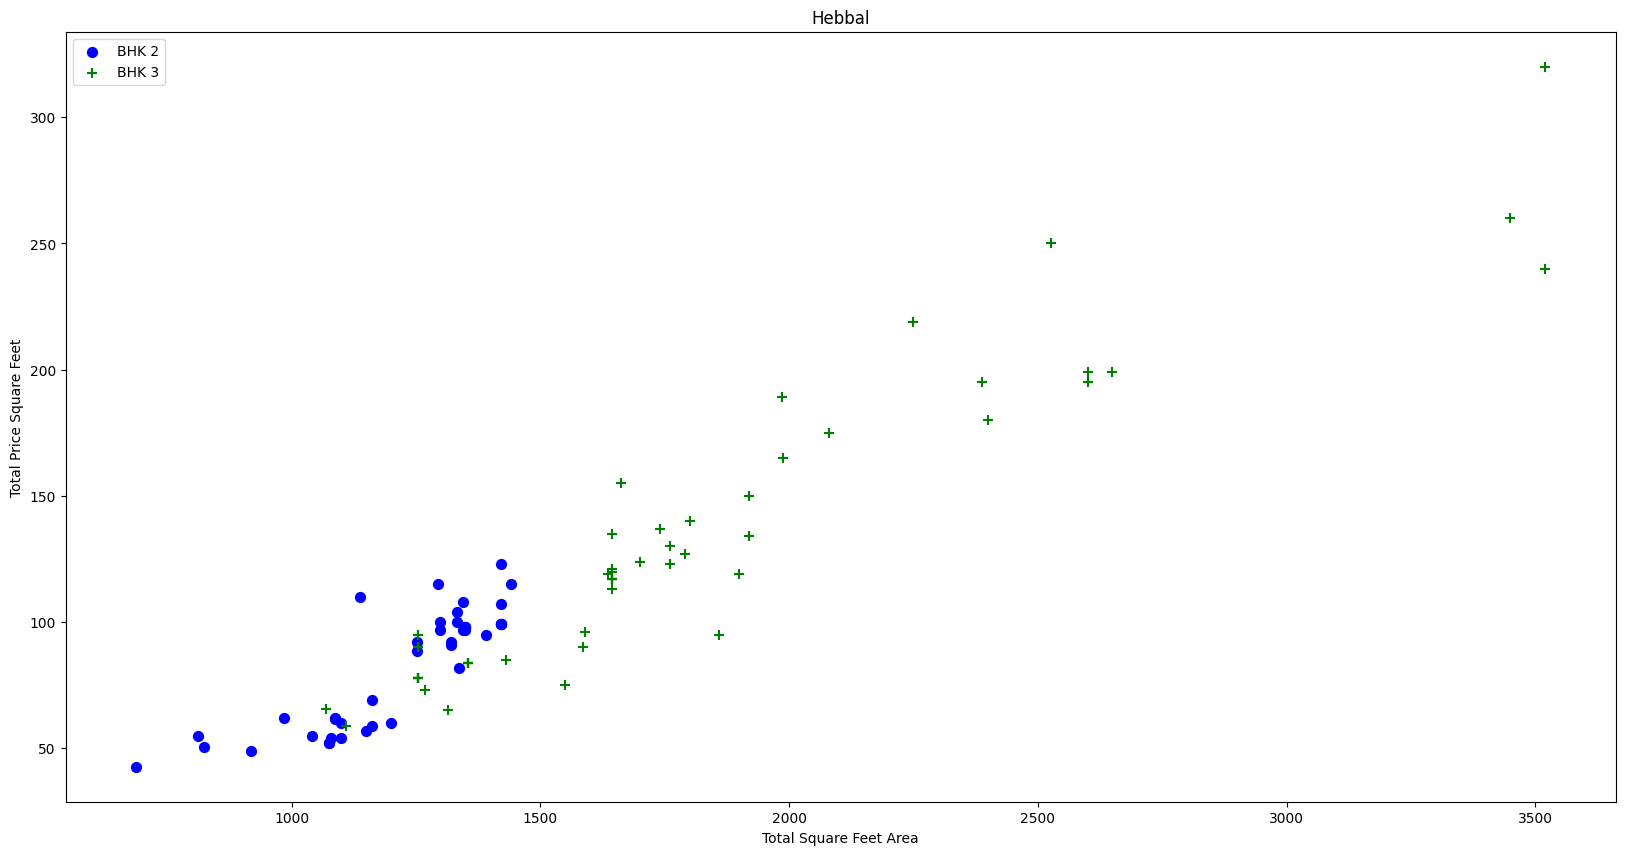

In [32]:
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    plt.scatter(bhk2.total_sqft, bhk2.price, color="blue", label="BHK 2", s=50)
    plt.scatter(
        bhk3.total_sqft,
        bhk3.price,
        marker="+",
        color="green",
        label="BHK 3",
        s=50,
    )
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Total Price Square Feet")
    plt.title(location)
    plt.legend()


plot_scatter_chart(df7, "Hebbal")

**We should also remove properties where for same location, the price of (for example) 3 bedroom apartment is less than 2 bedroom apartment (with same square ft area). What we will do is for a given location, we will build a dictionary of stats per bhk, i.e.**
```
{
    '1' : {
        'mean': 4000,
        'std: 2000,
        'count': 34
    },
    '2' : {
        'mean': 4300,
        'std: 2300,
        'count': 22
    },    
}
```
**Now we can remove those 2 BHK apartments whose price_per_sqft is less than mean price_per_sqft of 1 BHK apartment**

<h2 style="color:red">Explanation :</h2>
<h4>get for example bhk=2 for specific location and check : 
if the price per sqft for the houses that have 2 BHK in this location is lower than the mean of the houses that have 1 BHK in the same location so this is doesn`t make sense at all so this values are excluded and I have to drop it</h4>

In [33]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby("location"):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby("bhk"):
            bhk_stats[bhk] = {
                "mean": np.mean(bhk_df.price_per_sqft),
                "std": np.std(bhk_df.price_per_sqft),
                "count": bhk_df.shape[0],
            }
        for bhk, bhk_df in location_df.groupby("bhk"):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats["count"] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < (stats["mean"])].index.values,
                )
    return df.drop(exclude_indices, axis="index")


df8 = remove_bhk_outliers(df7)
df8.shape

(7329, 7)

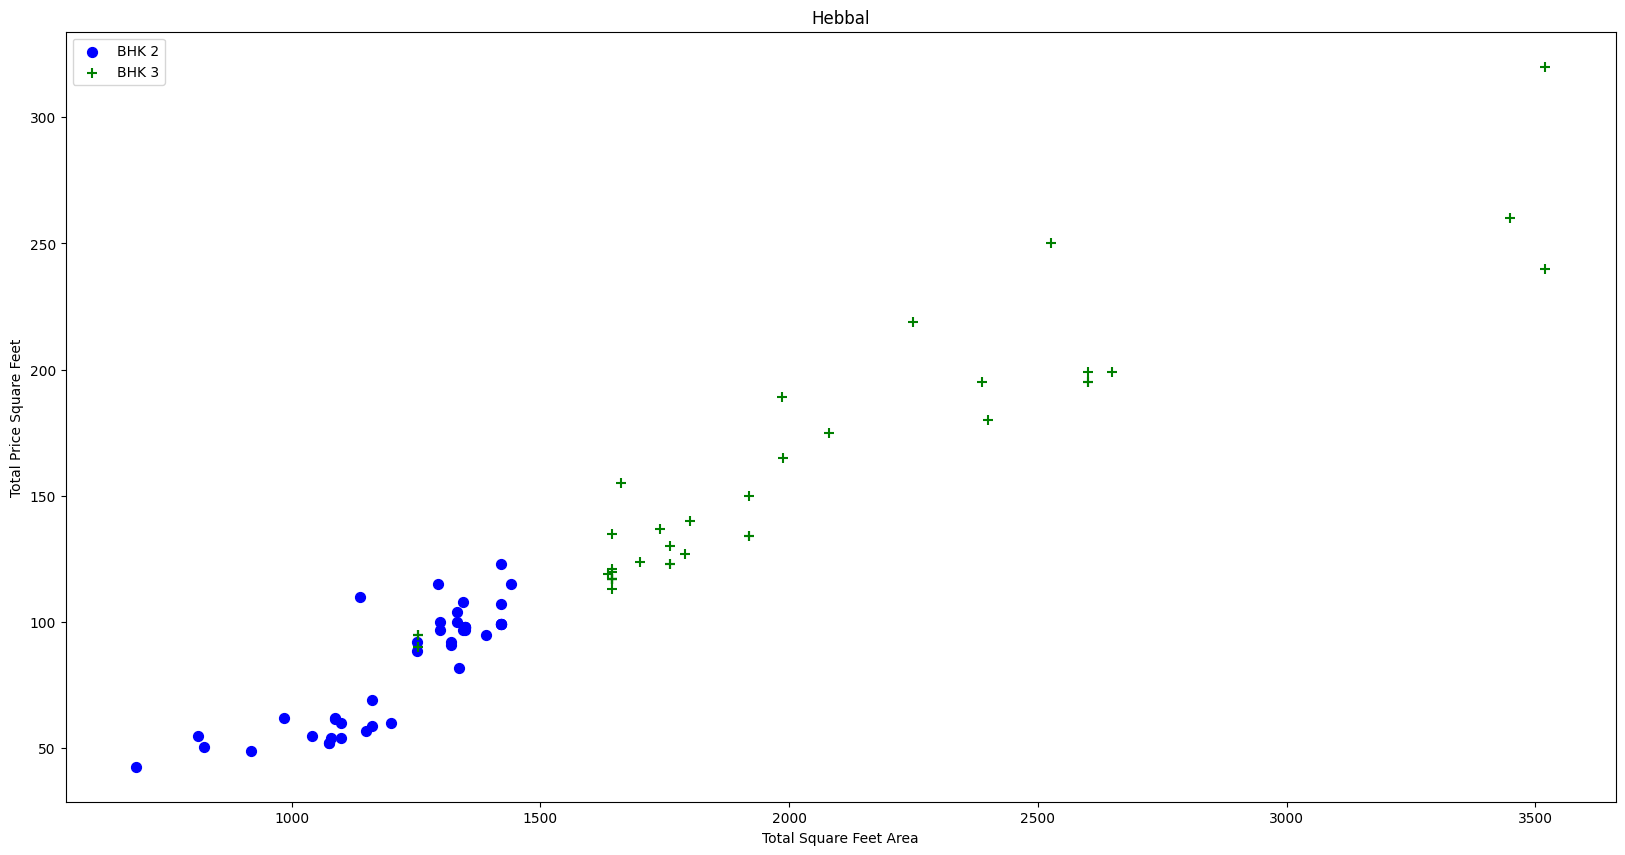

In [34]:
plot_scatter_chart(df8, "Hebbal")

Text(0, 0.5, 'Count')

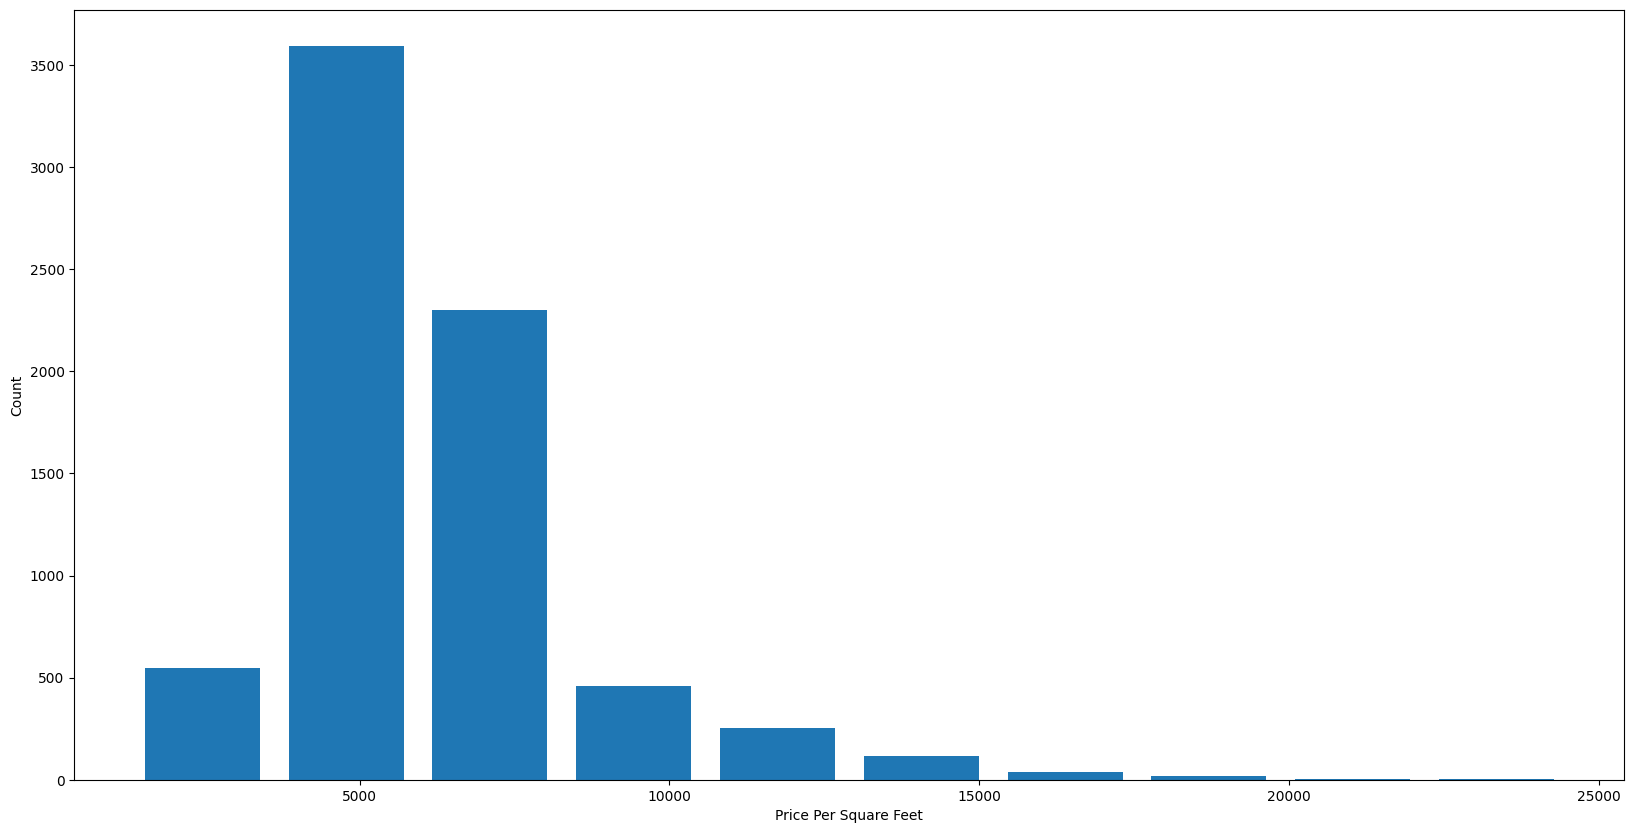

In [35]:
plt.hist(df8.price_per_sqft, rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

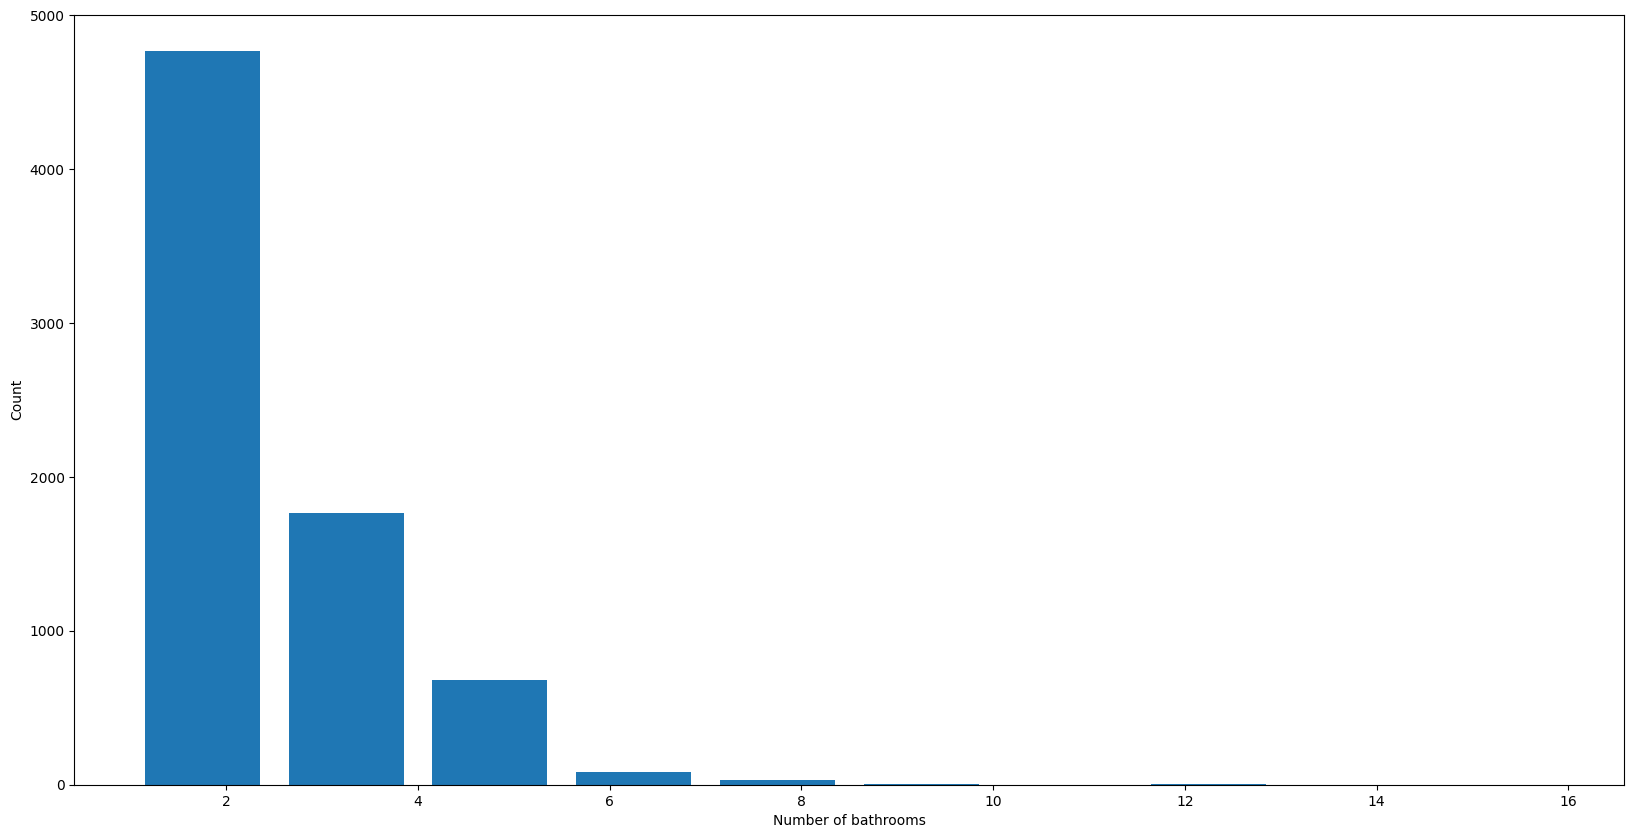

In [36]:
plt.hist(df8.bath, rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [37]:
df8[df8.bath > 10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8486,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8575,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9308,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9639,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


In [38]:
df9 = df8[df8.bath < df8.bhk + 2]
df9.shape

(7251, 7)

In [39]:
df10 = df9.drop(["size", "price_per_sqft"], axis="columns")
df10.head(5)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


<h2 style="color: blue; ">
Change Non-Numerical values To Numerical values :
</h2>
<h4>
we want to transform location to numerical column using one hot encoding .
</h4>


<h1 style="color: green;">One Hot Encoding :</h1>

<i><p>we take location categories and make it as columns elements instead of rows 
and in each record 1 column will be 1 and the others will be 0</p></i>

In [40]:
dummies = pd.get_dummies(df10.location)
dummies

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10232,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10233,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10236,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10237,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [41]:
df11 = pd.concat([df10, dummies.drop("other", axis="columns")], axis="columns")
df11.head(10)

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,194.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,235.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,130.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,148.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1st Block Jayanagar,2750.0,4.0,413.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,1st Block Jayanagar,2450.0,4.0,368.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,1st Phase JP Nagar,1875.0,3.0,167.0,3,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,1st Phase JP Nagar,1500.0,5.0,85.0,5,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10,1st Phase JP Nagar,2065.0,4.0,210.0,3,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [42]:
df12 = df11.drop("location", axis="columns")
df12.head(10)

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,130.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,148.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,2750.0,4.0,413.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,2450.0,4.0,368.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,1875.0,3.0,167.0,3,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,1500.0,5.0,85.0,5,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10,2065.0,4.0,210.0,3,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [43]:
df12.shape

(7251, 245)

In [45]:
X = df12.drop("price", axis="columns")
X.head(10)

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,2750.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,2450.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,1875.0,3.0,3,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,1500.0,5.0,5,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10,2065.0,4.0,3,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [48]:
y = df12.price
y.head()

0    428.0
1    194.0
2    235.0
3    130.0
4    148.0
Name: price, dtype: float64

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

<h1>Score Method :</h1>

When you call `lr_clf.score(X_test, y_test)` on a regression model like `LinearRegression`, it calculates the **R² score** for the predictions made by the model on the test data (`X_test`) compared to the true target values (`y_test`).

#### Formula for R² Score:
$$
R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
$$

Where:
- $ \text{SS}_{\text{res}} $: **Residual Sum of Squares** (the error between predicted and actual values).
  $$
  \text{SS}_{\text{res}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2
  $$
  Here:
  - $ y_i $: Actual target value.
  - $ \hat{y}_i $: Predicted target value.

- $ \text{SS}_{\text{tot}} $: **Total Sum of Squares** (the variance of the actual target values).
  $$
  \text{SS}_{\text{tot}} = \sum_{i=1}^n (y_i - \bar{y})^2
  $$
  Here:
  - $ \bar{y} $: Mean of the actual target values.

#### Interpretation of R²:
- **R² = 1**: Perfect prediction. The model explains all the variance in the target variable.
- **R² = 0**: The model performs no better than predicting the mean of the target variable.
- **R² < 0**: The model performs worse than predicting the mean (this can happen if the model is very poor or overfit).

In [ ]:
from sklearn.linear_model import LinearRegression

lr_clf = LinearRegression()
lr_clf.fit(X_train, y_train)
lr_clf.score(X_test, y_test)

0.8452277697874226

In [52]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.82430186, 0.77166234, 0.85089567, 0.80837764, 0.83653286])

In [55]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_best_model_using_gridsearchcv(X, y):
    algos = {
        "linear_regression": {
            "model": Pipeline(
                [
                    ("scaler", StandardScaler()),  # Add feature scaling
                    ("regressor", LinearRegression()),
                ]
            ),
            "params": {
                # No parameters for LinearRegression
            },
        },
        "lasso": {
            "model": Lasso(),
            "params": {"alpha": [1, 2], "selection": ["random", "cyclic"]},
        },
        "decision_tree": {
            "model": DecisionTreeRegressor(),
            "params": {
                "criterion": ["squared_error", "friedman_mse"],  # Updated criterion
                "splitter": ["best", "random"],
            },
        },
    }
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    for algo_name, config in algos.items():
        gs = GridSearchCV(
            config["model"], config["params"], cv=cv, return_train_score=False
        )
        gs.fit(X, y)
        scores.append(
            {
                "model": algo_name,
                "best_score": gs.best_score_,
                "best_params": gs.best_params_,
            }
        )

    return pd.DataFrame(scores, columns=["model", "best_score", "best_params"])


find_best_model_using_gridsearchcv(X, y)

,model,best_score,best_params
0,linear_regression,0.818354,{}
1,lasso,0.687467,"{'alpha': 1, 'selection': 'random'}"
2,decision_tree,0.723792,"{'criterion': 'friedman_mse', 'splitter': 'best'}"


In [56]:
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(X.columns == location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1

    return lr_clf.predict([x])[0]

In [57]:
predict_price("1st Phase JP Nagar", 1000, 2, 2)

d:\MY_PROJECTS\Git-Hub\Price-House-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


83.4990467714689

In [58]:
predict_price("1st Phase JP Nagar", 1000, 3, 3)

d:\MY_PROJECTS\Git-Hub\Price-House-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


86.80519395173319

In [59]:
predict_price("Indira Nagar", 1000, 2, 2)

d:\MY_PROJECTS\Git-Hub\Price-House-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


181.27815484007417

In [60]:
predict_price("Indira Nagar", 1000, 3, 3)

d:\MY_PROJECTS\Git-Hub\Price-House-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


184.58430202033847

<h2 style='color:blue'>Export the tested model to a pickle file</h2>

In [61]:
import pickle

with open("banglore_home_prices_model.pickle", "wb") as f:
    pickle.dump(lr_clf, f)

<h2 style='color:blue'>Export location and column information to a file that will be useful later on in our prediction application</h2>

In [62]:
import json

columns = {"data_columns": [col.lower() for col in X.columns]}
with open("columns.json", "w") as f:
    f.write(json.dumps(columns))